In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.ticker import PercentFormatter

In [16]:
def plot_histograms(model,dataset,gammas,load_path,save_path):
        
    fig, ax = plt.subplots(len(gammas),3, figsize=(20,50))
    plt.subplots_adjust(hspace=0.5)
    
    for i,gamma in enumerate(gammas):
        gamma = round(gamma,1)

        if not os.path.exists(f"{load_path}/results_{gamma}.csv"):
            continue

        data = pd.read_csv(f"{load_path}/results_{gamma}.csv")
        entr1 = data["entropy_1"].to_numpy()
        entr2 = data["entropy_2"].to_numpy()
        entr3 = data["mean_entropy_3_scaled"].to_numpy()
        S = data["S"].to_numpy()

        # Split into privileged and unprivileged group
        
        weights1 = weights=np.ones(len(entr1)) / len(entr1)
        weights2 = weights=np.ones(len(entr2)) / len(entr2)
        weights3 = weights=np.ones(len(entr3)) / len(entr3)     
        ax[i,0].hist(entr1, bins=20, range=(0,1), color="skyblue",edgecolor='blue', alpha=0.2,weights=weights1)
        ax[i,0].hist(entr1, bins=20, range=(0,1), color="skyblue",edgecolor='blue', alpha=1,weights=weights1, fill=False,label="1)")
        ax[i,0].hist(entr2, bins=20, range=(0,1), color='limegreen', alpha=0.2,weights=weights2)
        ax[i,0].hist(entr2, bins=20, range=(0,1), edgecolor='green', alpha=1,weights=weights2, fill=False,label="2)")
        ax[i,0].hist(entr3, bins=20, range=(0,1), edgecolor='coral', alpha=0.2,weights=weights3)
        ax[i,0].hist(entr3, bins=20, range=(0,1), edgecolor='red', alpha=1,weights=weights3, fill=False,label="3)")
        ax[i,0].set_title(f"Gamma = {gamma} |   All Groups")
        ax[i,0].set_xlabel('Entropy')
        #ax[i,0].set_ylabel('Number')
        ax[i,0].grid(True, linestyle=':', alpha=0.6)
        ax[i,0].set_xlim(0,1)
        #mean = np.mean(entr_res)
        #std = np.std(entr_res)
        #ax[i,0].axvline(mean, color='blue', linestyle='dashed', linewidth=2)
        #ax[i,0].axvline(mean + std, color='grey', linestyle='dashed', linewidth=1)
        #ax[i,0].axvline(mean - std, color='grey', linestyle='dashed', linewidth=1)
        ax[i,0].set_ylim(0,1)
        ax[i,0].yaxis.set_major_formatter(PercentFormatter(1))


        entr1_priv=entr1[np.where(S == 1)]
        entr2_priv=entr2[np.where(S == 1)]
        entr3_priv=entr3[np.where(S == 1)]
        weights1 = weights=np.ones(len(entr1_priv)) / len(entr1_priv)
        weights2 = weights=np.ones(len(entr2_priv)) / len(entr2_priv)
        weights3 = weights=np.ones(len(entr3_priv)) / len(entr3_priv)
        ax[i,1].hist(entr1_priv, bins=20, range=(0,1), color="skyblue",edgecolor='blue', alpha=0.2,weights=weights1)
        ax[i,1].hist(entr1_priv, bins=20, range=(0,1), color="skyblue",edgecolor='blue', alpha=1,weights=weights1, fill=False,label="1)")
        ax[i,1].hist(entr2_priv, bins=20, range=(0,1), color='limegreen', alpha=0.2,weights=weights2)
        ax[i,1].hist(entr2_priv, bins=20, range=(0,1), edgecolor='green', alpha=1,weights=weights2, fill=False,label="2)")
        ax[i,1].hist(entr3_priv, bins=20, range=(0,1), edgecolor='coral', alpha=0.2,weights=weights3)
        ax[i,1].hist(entr3_priv, bins=20, range=(0,1), edgecolor='red', alpha=1,weights=weights3, fill=False,label="3)")
        ax[i,1].set_title('S=1')
        ax[i,1].set_xlabel('Entropy')
        #ax[i,1].set_ylabel('Number')
        ax[i,1].grid(True, linestyle=':', alpha=0.6)
        ax[i,1].set_xlim(0,1)
        #mean = np.mean(res_priv)
        #std = np.std(res_priv)
        #ax[i,1].axvline(mean, color='green', linestyle='dashed', linewidth=2)
        #ax[i,1].axvline(mean + std, color='grey', linestyle='dashed', linewidth=1)
        #ax[i,1].axvline(mean - std, color='grey', linestyle='dashed', linewidth=1)
        ax[i,1].set_ylim(0,1)
        ax[i,1].yaxis.set_major_formatter(PercentFormatter(1))

        entr1_unpriv=entr1[np.where(S == 0)]
        entr2_unpriv=entr2[np.where(S == 0)]
        entr3_unpriv=entr3[np.where(S == 0)]
        weights1 = weights=np.ones(len(entr1_unpriv)) / len(entr1_unpriv)
        weights2 = weights=np.ones(len(entr2_unpriv)) / len(entr2_unpriv)
        weights3 = weights=np.ones(len(entr3_unpriv)) / len(entr3_unpriv)
        ax[i,2].hist(entr1_unpriv, bins=20, range=(0,1), color="skyblue",edgecolor='blue', alpha=0.2,weights=weights1)
        ax[i,2].hist(entr1_unpriv, bins=20, range=(0,1), color="skyblue",edgecolor='blue', alpha=1,weights=weights1, fill=False,label="1)")
        ax[i,2].hist(entr2_unpriv, bins=20, range=(0,1), color='limegreen', alpha=0.2,weights=weights2)
        ax[i,2].hist(entr2_unpriv, bins=20, range=(0,1), edgecolor='green', alpha=1,weights=weights2, fill=False,label="2)")
        ax[i,2].hist(entr3_unpriv, bins=20, range=(0,1), edgecolor='coral', alpha=0.2,weights=weights3)
        ax[i,2].hist(entr3_unpriv, bins=20, range=(0,1), edgecolor='red', alpha=1,weights=weights3, fill=False,label="3)")
        ax[i,2].set_title('S=0')
        ax[i,2].set_xlabel('Entropy')
        #ax[i,2].set_ylabel('Number')
        ax[i,2].grid(True, linestyle=':', alpha=0.6)
        ax[i,2].set_xlim(0,1)
        #mean = np.mean(res_unpriv)
        #std = np.std(res_unpriv)
        #ax[i,2].axvline(mean, color='red', linestyle='dashed', linewidth=2)
        #ax[i,2].axvline(mean + std, color='grey', linestyle='dashed', linewidth=1)
        #ax[i,2].axvline(mean - std, color='grey', linestyle='dashed', linewidth=1)
        ax[i,2].set_ylim(0,1)
        ax[i,2].yaxis.set_major_formatter(PercentFormatter(1))

    ax[0,0].legend()
    plt.savefig(f"{save_path}/{dataset}_{model}_entropy_predictions.pdf")

In [17]:
def plot_histograms_expgrad(model,dataset,gammas,load_path,save_path):
        
    fig, ax = plt.subplots(len(gammas),3, figsize=(20,50))
    plt.subplots_adjust(hspace=0.5)
    
    for i,gamma in enumerate(gammas):
        gamma = round(gamma,3)

        data = pd.read_csv(f"{load_path}/results_{gamma}.csv")
        entr = data["entropy_1"].to_numpy()#recalculate_entropy(f"{load_path}/results_{gamma}.csv")
        entr_res = entr
        S = data["S"].to_numpy()

        # Split into privileged and unprivileged group
        res_priv = entr_res[np.where(S == 1)]
        res_unpriv = entr_res[np.where(S == 0)]
        
        weights = weights=np.ones(len(entr_res)) / len(entr_res)
        ax[i,0].hist(entr_res, bins=20, range=(0,1), color='skyblue', edgecolor='blue', alpha=0.2,weights=weights)
        ax[i,0].hist(entr_res, bins=20, range=(0,1), color='skyblue', edgecolor='blue', alpha=1,weights=weights,fill=False)
        ax[i,0].set_title(f"Epsilon = {gamma} |   All Groups")
        ax[i,0].set_xlabel('Entropy')
        #ax[i,0].set_ylabel('Number')
        ax[i,0].grid(True, linestyle=':', alpha=0.6)
        ax[i,0].set_xlim(0,1)
        #mean = np.mean(entr_res)
        #std = np.std(entr_res)
        #ax[i,0].axvline(mean, color='blue', linestyle='dashed', linewidth=2)
        #ax[i,0].axvline(mean + std, color='grey', linestyle='dashed', linewidth=1)
        #ax[i,0].axvline(mean - std, color='grey', linestyle='dashed', linewidth=1)
        ax[i,0].set_ylim(0,1)
        ax[i,0].yaxis.set_major_formatter(PercentFormatter(1))

        weights = weights=np.ones(len(res_priv)) / len(res_priv)
        ax[i,1].hist(res_priv, bins=20,range=(0,1), color='skyblue', edgecolor='blue', alpha=0.2,weights=weights)
        ax[i,1].hist(res_priv, bins=20,range=(0,1), color='skyblue', edgecolor='blue', alpha=1,weights=weights,fill=False)
        ax[i,1].set_title('S=1')
        ax[i,1].set_xlabel('Entropy')
        #ax[i,1].set_ylabel('Number')
        ax[i,1].grid(True, linestyle=':', alpha=0.6)
        ax[i,1].set_xlim(0,1)
        #mean = np.mean(res_priv)
        #std = np.std(res_priv)
        #ax[i,1].axvline(mean, color='green', linestyle='dashed', linewidth=2)
        #ax[i,1].axvline(mean + std, color='grey', linestyle='dashed', linewidth=1)
        #ax[i,1].axvline(mean - std, color='grey', linestyle='dashed', linewidth=1)
        ax[i,1].set_ylim(0,1)
        ax[i,1].yaxis.set_major_formatter(PercentFormatter(1))

        weights = weights=np.ones(len(res_unpriv)) / len(res_unpriv)
        ax[i,2].hist(res_unpriv, bins=20,range=(0,1), color='skyblue', edgecolor='blue', alpha=0.2,weights=weights)
        ax[i,2].hist(res_unpriv, bins=20,range=(0,1), color='skyblue', edgecolor='blue', alpha=1,weights=weights,fill=False)
        ax[i,2].set_title('S=0')
        ax[i,2].set_xlabel('Entropy')
        #ax[i,2].set_ylabel('Number')
        ax[i,2].grid(True, linestyle=':', alpha=0.6)
        ax[i,2].set_xlim(0,1)
        #mean = np.mean(res_unpriv)
        #std = np.std(res_unpriv)
        #ax[i,2].axvline(mean, color='red', linestyle='dashed', linewidth=2)
        #ax[i,2].axvline(mean + std, color='grey', linestyle='dashed', linewidth=1)
        #ax[i,2].axvline(mean - std, color='grey', linestyle='dashed', linewidth=1)
        ax[i,2].set_ylim(0,1)
        ax[i,2].yaxis.set_major_formatter(PercentFormatter(1))

    plt.savefig(f"{save_path}/{dataset}_{model}_entropy_predictions.pdf")

In [18]:
def plot_tradeoff(model,dataset,load_path,save_path):
    data = pd.read_csv(f"{load_path}/accuracies.csv")
    fig, ax = plt.subplots(1,2, figsize=(20,10))
    ax[0].scatter(1-data["dp"],data["acc"],s=data["gamma"]*40+1)
    ax[0].plot(1-data["dp"],data["acc"],alpha=0.3)
    ax[0].set_ylim(0,1)
    for i, txt in enumerate(data["gamma"]):
        ax[0].annotate(round(txt,1), (1-data["dp"][i], data["acc"][i]))
    ax[0].set_xlabel("1-Demographic Parity Difference")
    ax[0].set_ylabel("Acccuracy")
    ax[1].scatter(1-data["dp_threshold"],data["acc_threshold"],s=data["gamma"]*40+1)
    ax[1].plot(1-data["dp_threshold"],data["acc_threshold"],alpha=0.3)
    ax[1].set_ylim(0,1)
    for i, txt in enumerate(data["gamma"]):
        ax[1].annotate(round(txt,1), (1-data["dp_threshold"][i], data["acc_threshold"][i]))
    ax[1].set_xlabel("1 - Demographic Parity Difference")
    plt.savefig(f"{save_path}/{dataset}_{model}_tradeoff.pdf")

In [19]:
def plot_tradeoff_expgrad(model,dataset,load_path,save_path):
    data = pd.read_csv(f"{load_path}/accuracies.csv")
    fig, ax = plt.subplots(1,2, figsize=(20,10))
    ax[0].scatter(1-data["dp"],data["acc"],s=data["epsilon"]*400)
    ax[0].plot(1-data["dp"],data["acc"],alpha=0.3)
    ax[0].set_ylim(0,1)
    for i, txt in enumerate(data["epsilon"]):
        ax[0].annotate(round(txt,3), (1-data["dp"][i], data["acc"][i]))
    ax[0].set_xlabel("1-Demographic Parity Difference")
    ax[0].set_ylabel("Acccuracy")
    ax[1].set_ylim(0,1)
    plt.savefig(f"{save_path}/{dataset}_{model}_tradeoff.pdf")

In [20]:
def plot_avg_entropy(model,dataset,load_path,save_path):
    fig, ax = plt.subplots(1,3,figsize=(20,10))
    entr1_mean = []
    entr1_std = []
    entr2_mean = []
    entr2_std = []
    entr3_mean = []
    entr3_std = []

    entr1_mean_unpriv = []
    entr1_std_unpriv = []
    entr2_mean_unpriv = []
    entr2_std_unpriv = []
    entr3_mean_unpriv = []
    entr3_std_unpriv = []

    entr1_mean_priv = []
    entr1_std_priv = []
    entr2_mean_priv = []
    entr2_std_priv = []
    entr3_mean_priv = []
    entr3_std_priv = []

    max_gamma=None
    gammas = np.linspace(0,1,11)
    for i,gamma in enumerate(gammas):
        gamma = round(gamma,1)

        if not os.path.exists(f"{load_path}/results_{gamma}.csv"):
            continue
        else:
            max_gamma = i

        data = pd.read_csv(f"{load_path}/results_{gamma}.csv")
        entr1 = data["entropy_1"].to_numpy()
        entr2 = data["entropy_2"].to_numpy()
        entr3 = data["mean_entropy_3_scaled"].to_numpy()
        S = data["S"].to_numpy()

        entr1_unpriv = entr1[np.where(S == 0)]
        entr2_unpriv = entr2[np.where(S == 0)]
        entr3_unpriv = entr3[np.where(S == 0)]

        entr1_priv = entr1[np.where(S == 1)]
        entr2_priv = entr2[np.where(S == 1)]
        entr3_priv = entr3[np.where(S == 1)]

        entr1_mean.append(np.mean(entr1))
        entr1_std.append(np.std(entr1))
        entr2_mean.append(np.mean(entr2))
        entr2_std.append(np.std(entr2))
        entr3_mean.append(np.mean(entr3))
        entr3_std.append(np.std(entr3))

        entr1_mean_unpriv.append(np.mean(entr1_unpriv))
        entr1_std_unpriv.append(np.std(entr1_unpriv))
        entr2_mean_unpriv.append(np.mean(entr2_unpriv))
        entr2_std_unpriv.append(np.std(entr2_unpriv))
        entr3_mean_unpriv.append(np.mean(entr3_unpriv))
        entr3_std_unpriv.append(np.std(entr3_unpriv))

        entr1_mean_priv.append(np.mean(entr1_priv))
        entr1_std_priv.append(np.std(entr1_priv))
        entr2_mean_priv.append(np.mean(entr2_priv))
        entr2_std_priv.append(np.std(entr2_priv))
        entr3_mean_priv.append(np.mean(entr3_priv))
        entr3_std_priv.append(np.std(entr3_priv))
    
    ax[0].errorbar(gammas[:max_gamma+1], entr1_mean, yerr=entr1_std,capsize=3, fmt="--o",color="mediumpurple",label="1)")
    ax[0].errorbar(gammas[:max_gamma+1], entr2_mean, yerr=entr2_std,capsize=3, fmt="--o",color="limegreen",label="2)")
    ax[0].errorbar(gammas[:max_gamma+1], entr3_mean, yerr=entr3_std,capsize=3, fmt="--o",color="coral",label="3)")
    ax[0].set_title("All sens. groups")
    ax[0].set_xlabel("Gamma")
    ax[0].set_ylabel("Entropy")
    ax[0].set_ylim(-0.1,1.1)
    ax[0].legend()

    ax[1].errorbar(gammas[:max_gamma+1], entr1_mean_unpriv, yerr=entr1_std_unpriv,capsize=3, fmt="--o",color="mediumpurple")
    ax[1].errorbar(gammas[:max_gamma+1], entr2_mean_unpriv, yerr=entr2_std_unpriv,capsize=3, fmt="--o",color="limegreen")
    ax[1].errorbar(gammas[:max_gamma+1], entr3_mean_unpriv, yerr=entr3_std_unpriv,capsize=3, fmt="--o",color="coral")
    ax[1].set_title("S=0")
    ax[1].set_xlabel("Gamma")
    ax[1].set_ylim(-0.1,1.1)

    ax[2].errorbar(gammas[:max_gamma+1], entr1_mean_priv, yerr=entr1_std_priv,capsize=3, fmt="--o",color="mediumpurple")
    ax[2].errorbar(gammas[:max_gamma+1], entr2_mean_priv, yerr=entr2_std_priv,capsize=3, fmt="--o",color="limegreen")
    ax[2].errorbar(gammas[:max_gamma+1], entr3_mean_priv, yerr=entr3_std_priv,capsize=3, fmt="--o",color="coral")
    ax[2].set_title("S=1")
    ax[2].set_xlabel("Gamma")
    ax[2].set_ylim(-0.1,1.1)
    plt.savefig(f"{save_path}/{dataset}_{model}_avg_entropy.pdf")


In [21]:
def plot_avg_entropy_expgrad(model,dataset,load_path,save_path):
    fig, ax = plt.subplots(1,3,figsize=(20,10))
    entr1_mean = []
    entr1_std = []

    entr1_mean_unpriv = []
    entr1_std_unpriv = []

    entr1_mean_priv = []
    entr1_std_priv = []

    epsilons = np.linspace(0.01,0.1,11)
    for i,eps in enumerate(epsilons):
        eps = round(eps,3)

        if not os.path.exists(f"{load_path}/results_{eps}.csv"):
            continue

        data = pd.read_csv(f"{load_path}/results_{eps}.csv")
        entr1 = data["entropy_1"].to_numpy()
        S = data["S"].to_numpy()

        entr1_unpriv = entr1[np.where(S == 0)]

        entr1_priv = entr1[np.where(S == 1)]

        entr1_mean.append(np.mean(entr1))
        entr1_std.append(np.std(entr1))

        entr1_mean_unpriv.append(np.mean(entr1_unpriv))
        entr1_std_unpriv.append(np.std(entr1_unpriv))

        entr1_mean_priv.append(np.mean(entr1_priv))
        entr1_std_priv.append(np.std(entr1_priv))
    
    ax[0].errorbar(epsilons, entr1_mean, yerr=entr1_std,capsize=3, fmt="--o",color="mediumpurple")
    ax[0].set_title("All sens. groups")
    ax[0].set_xlabel("Gamma")
    ax[0].set_ylabel("Entropy")
    ax[0].set_ylim(-0.1,1.1)

    ax[1].errorbar(epsilons, entr1_mean_unpriv, yerr=entr1_std_unpriv,capsize=3, fmt="--o",color="mediumpurple")
    ax[1].set_title("S=0")
    ax[1].set_xlabel("Gamma")
    ax[1].set_ylim(-0.1,1.1)

    ax[2].errorbar(epsilons, entr1_mean_priv, yerr=entr1_std_priv,capsize=3, fmt="--o",color="mediumpurple")
    ax[2].set_title("S=1")
    ax[2].set_xlabel("Gamma")
    ax[2].set_ylim(-0.1,1.1)
    plt.savefig(f"{save_path}/{dataset}_{model}_avg_entropy.pdf")

In [22]:
def fairness_avg_entropy(model,dataset,load_path,save_path):
    fig, ax = plt.subplots(1,3,figsize=(20,10))
    entr1_mean = []
    entr1_std = []
    entr2_mean = []
    entr2_std = []
    entr3_mean = []
    entr3_std = []

    gammas = np.linspace(0,1,11)
    for i,gamma in enumerate(gammas):
        gamma = round(gamma,1)

        if not os.path.exists(f"{load_path}/results_{gamma}.csv"):
            continue

        data = pd.read_csv(f"{load_path}/results_{gamma}.csv")
        entr1 = data["entropy_1"].to_numpy()
        entr2 = data["entropy_2"].to_numpy()
        entr3 = data["mean_entropy_3_scaled"].to_numpy()
        S = data["S"].to_numpy()

        entr1_mean.append(np.mean(entr1))
        entr1_std.append(np.std(entr1))
        entr2_mean.append(np.mean(entr2))
        entr2_std.append(np.std(entr2))
        entr3_mean.append(np.mean(entr3))
        entr3_std.append(np.std(entr3))

    data = pd.read_csv(f"{load_path}/accuracies.csv")
    dp = data["dp"]

    ax[0].plot(1-dp, entr1_mean,"-o")
    ax[1].plot(1-data["dp_threshold"], entr2_mean,"-o")
    ax[2].plot(1-dp, entr3_mean,"-o")
    for i, txt in enumerate(data["gamma"]):
        ax[0].annotate(round(txt,1), (1-data["dp"][i], entr1_mean[i]))
        ax[1].annotate(round(txt,1), (1-data["dp_threshold"][i], entr2_mean[i]))
        ax[2].annotate(round(txt,1), (1-data["dp"][i], entr3_mean[i]))
    ax[0].set_xlabel("1- DP")
    ax[1].set_xlabel("1- DP")
    ax[2].set_xlabel("1- DP")
    ax[0].set_ylabel("Mean Entropy")
    ax[1].set_ylabel("Mean Entropy")
    ax[2].set_ylabel("Mean Entropy")
    ax[0].set_title("1)")
    ax[1].set_title("2)")
    ax[2].set_title("3)")
    ax[0].set_ylim(0,1)
    ax[1].set_ylim(0,1)
    ax[2].set_ylim(0,1)
    plt.savefig(f"{save_path}/{dataset}_{model}_fairness_entropy.pdf")

In [23]:
def fairness_avg_entropy_expgrad(model,dataset,load_path,save_path):
    fig, ax = plt.subplots(1,1,figsize=(7,10))
    entr1_mean = []
    entr1_std = []

    epsilons = np.linspace(0.01,0.1,11)
    for i,eps in enumerate(epsilons):
        eps = round(eps,3)

        if not os.path.exists(f"{load_path}/results_{eps}.csv"):
            continue

        data = pd.read_csv(f"{load_path}/results_{eps}.csv")
        entr1 = data["entropy_1"].to_numpy()
        S = data["S"].to_numpy()

        entr1_mean.append(np.mean(entr1))
        entr1_std.append(np.std(entr1))

    data = pd.read_csv(f"{load_path}/accuracies.csv")
    dp = data["dp"]

    ax.plot(1-dp, entr1_mean,"-o")
    for i, txt in enumerate(data["epsilon"]):
        ax.annotate(round(txt,3), (1-data["dp"][i], entr1_mean[i]))
    ax.set_xlabel("1- DP")
    ax.set_ylabel("Mean Entropy")
    ax.set_title("1)")
    ax.set_ylim(0,1)
    plt.savefig(f"{save_path}/{dataset}_{model}_fairness_entropy.pdf")

In [24]:
def correlation_plots(model,dataset,load_path,save_path):
    gammas = np.linspace(0,1,11)

    fig, ax = plt.subplots(len(gammas),3,figsize=(20,50))
    plt.subplots_adjust(hspace=0.5)

    for i,gamma in enumerate(gammas):
        gamma= round(gamma,1)
        if not os.path.exists(f"{load_path}/results_{gamma}.csv"):
            continue
        data = pd.read_csv(f"{load_path}/results_{gamma}.csv")
        entr1 = data["entropy_1"].to_numpy()
        entr2 = data["entropy_2"].to_numpy()
        entr3 = data["mean_entropy_3_scaled"].to_numpy()

        ax[i,0].scatter(entr1,entr2,s=2)
        ax[i,0].set_xlim(0,1)
        ax[i,0].set_ylim(0,1)
        ax[i,0].set_xlabel("Entropy 1")
        ax[i,0].set_ylabel("Entropy 2")
        ax[i,0].set_title(f"Gamma = {gamma}")

        ax[i,1].scatter(entr2,entr3,s=2)
        ax[i,1].set_xlim(0,1)
        ax[i,1].set_ylim(0,1)
        ax[i,1].set_xlabel("Entropy 2")
        ax[i,1].set_ylabel("Entropy 3")

        ax[i,2].scatter(entr1,entr3,s=2)
        ax[i,2].set_xlim(0,1)
        ax[i,2].set_ylim(0,1)
        ax[i,2].set_xlabel("Entropy 1")
        ax[i,2].set_ylabel("Entropy 3")

    plt.savefig(f"{save_path}/{dataset}_{model}_correlations_entropy.pdf")

In [25]:
def main(load_path,save_path):
    dirs = [x[0] for x in os.walk(load_path)]
    dirs.remove(load_path)
    dirs.remove(f"{load_path}/plots")
    gammas = np.linspace(0,1,11)
    epsilons = np.linspace(0.01, 0.1, 11)

    for d in dirs:
        splitted_path = d.split("/")[3].split("_") # Change that according to your path (the index in the [] should be the 
                                                    # one containing the dataset, modelname etc)
        dataset = splitted_path[0]
        if dataset == "folktables":
            dataset += "_"
            dataset += splitted_path[1]
            model = splitted_path[2]
        else:
            model = splitted_path[1]

        if model == "ExpGrad":
            plot_histograms_expgrad(model,dataset,epsilons,d,save_path)
            plot_tradeoff_expgrad(model,dataset,d,save_path)
            plot_avg_entropy_expgrad(model,dataset,d,save_path)
            fairness_avg_entropy_expgrad(model,dataset,d,save_path)
        else:
            plot_histograms(model,dataset,gammas,d,save_path)
            plot_tradeoff(model,dataset,d,save_path)
            plot_avg_entropy(model,dataset,d,save_path)
            fairness_avg_entropy(model,dataset,d,save_path)
            correlation_plots(model,dataset,d,save_path)

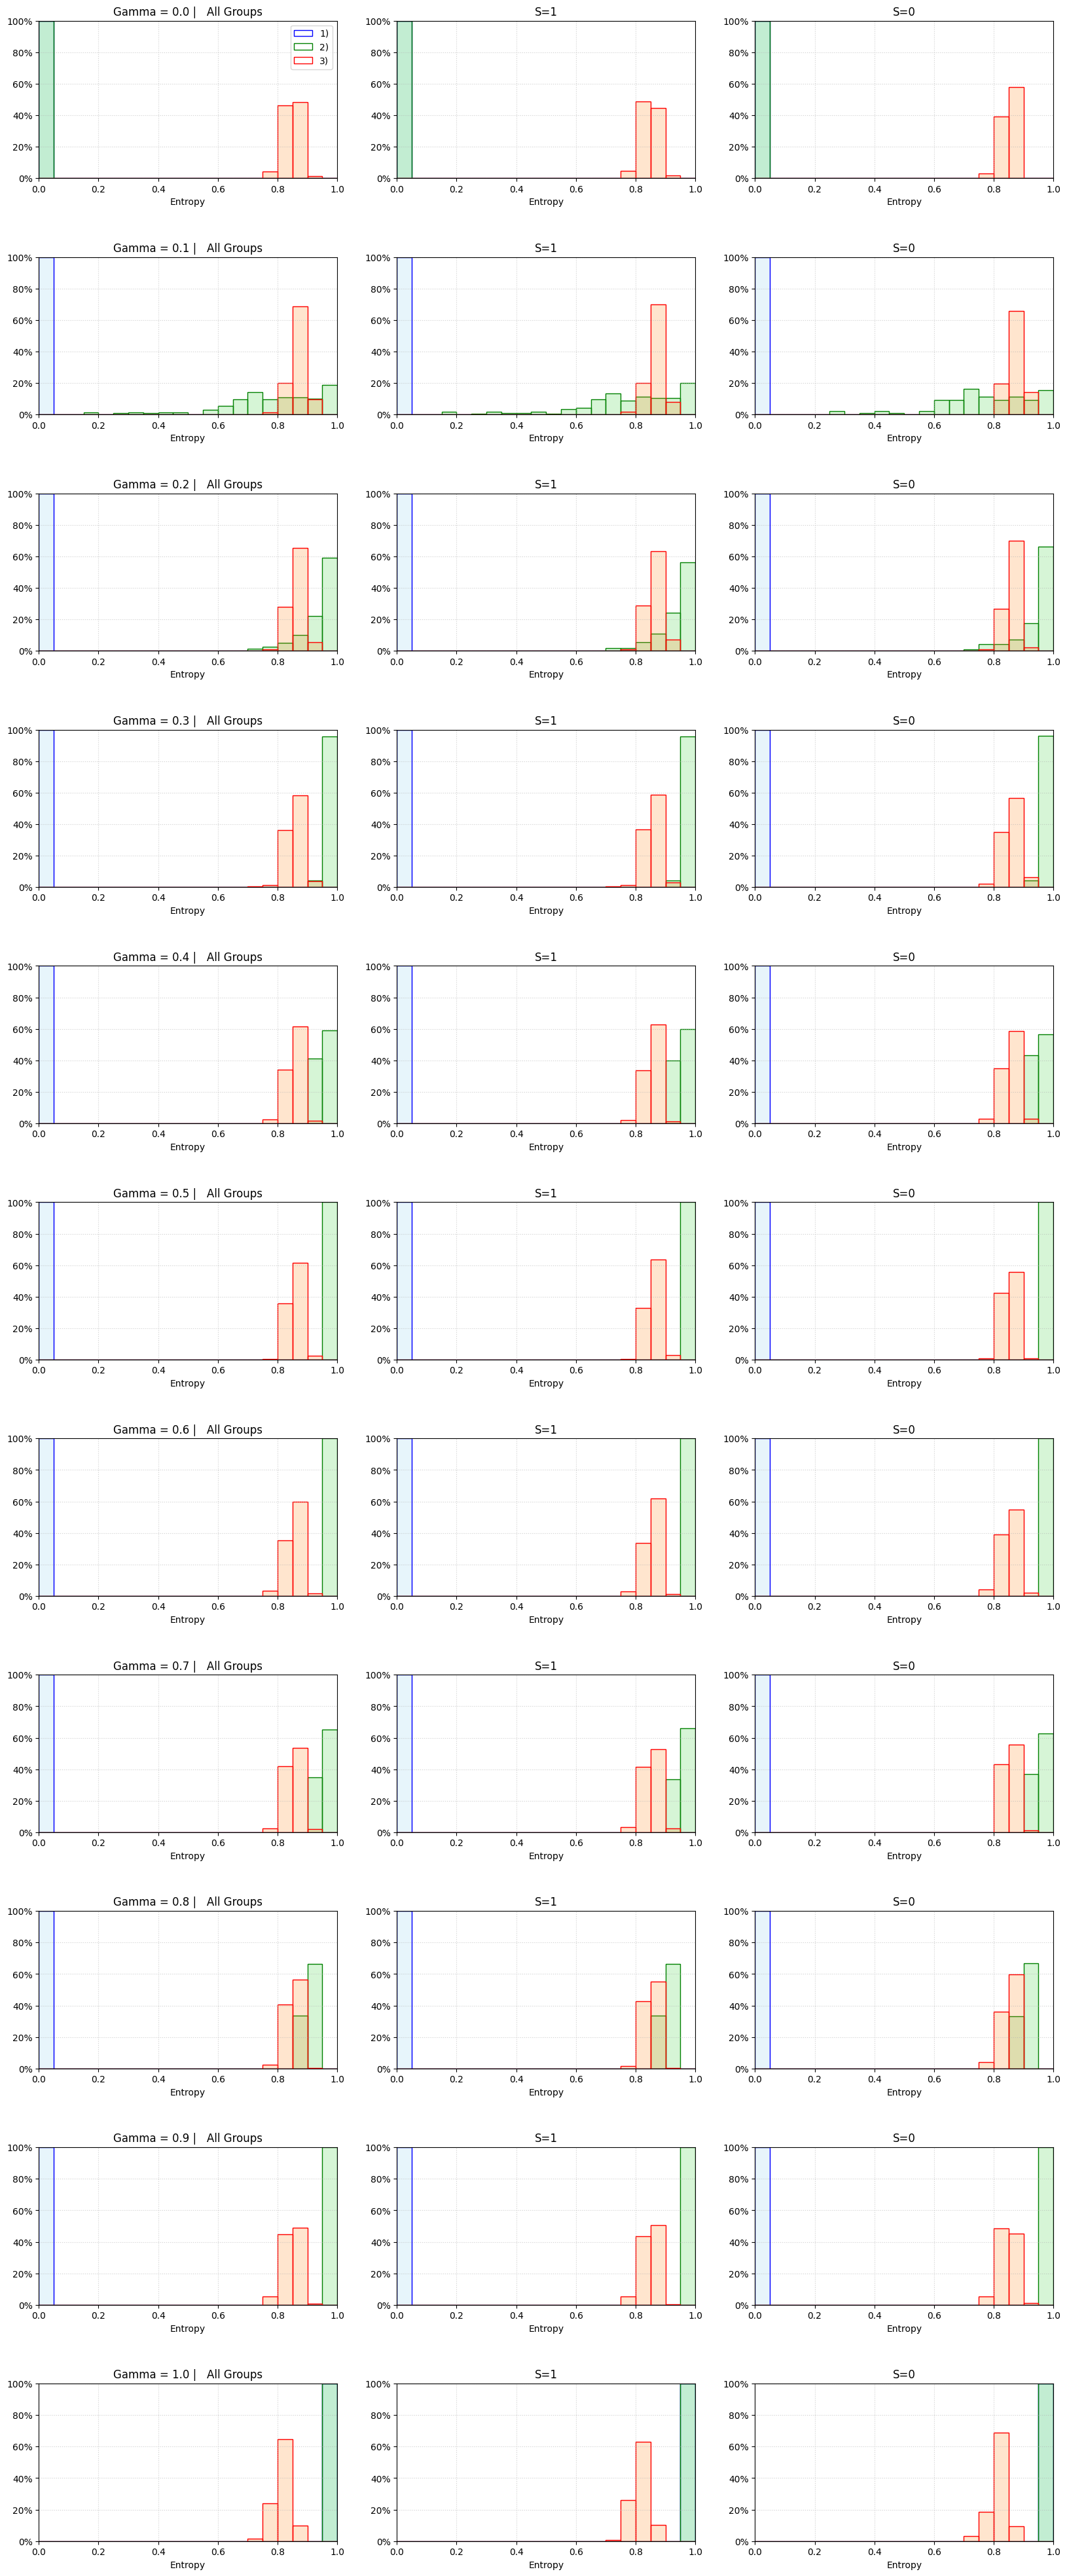

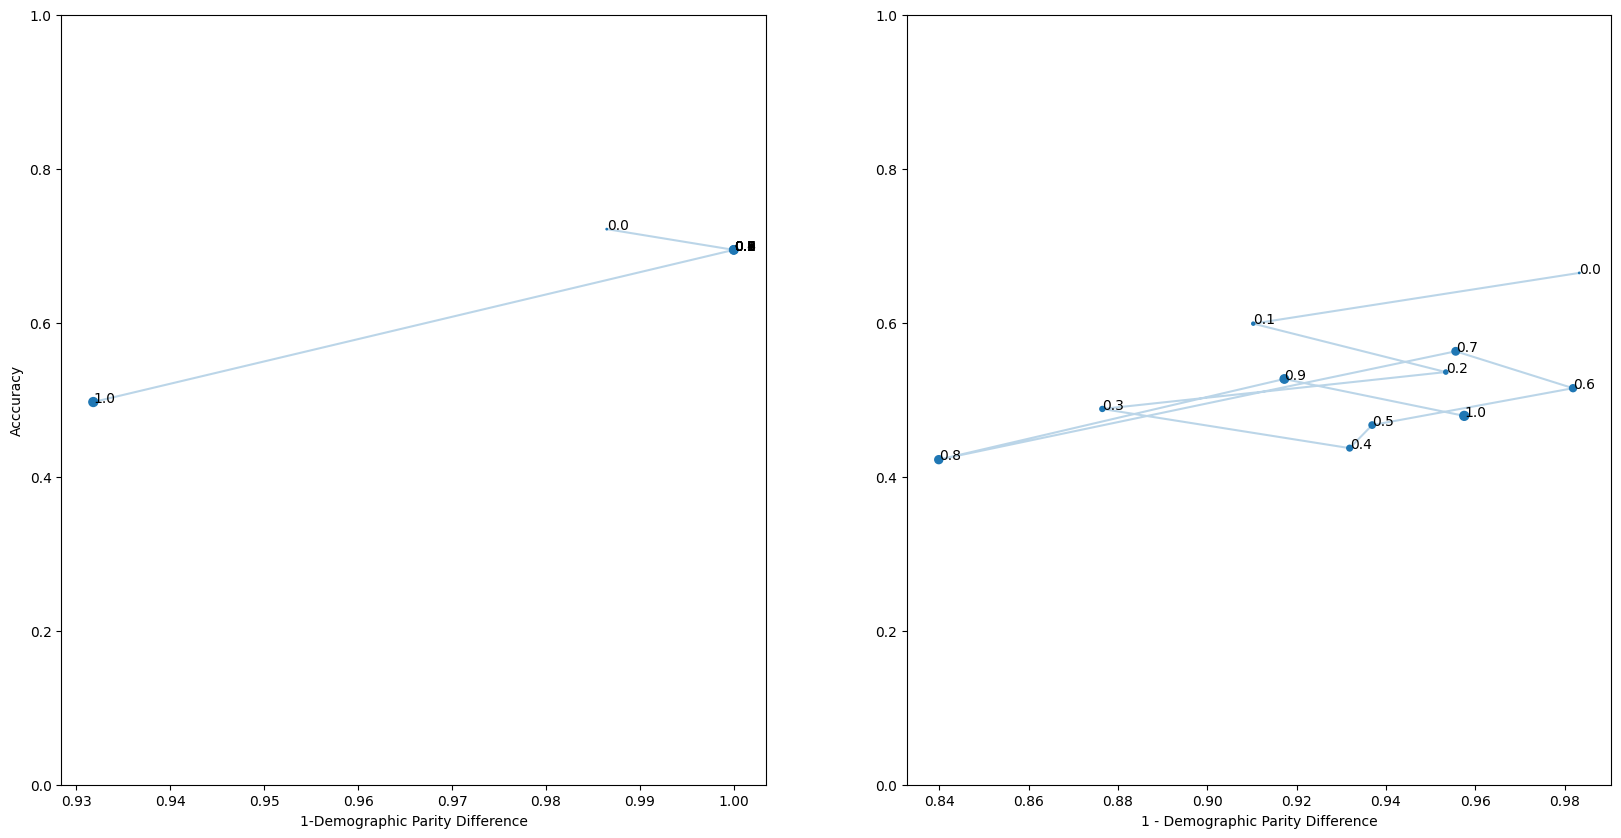

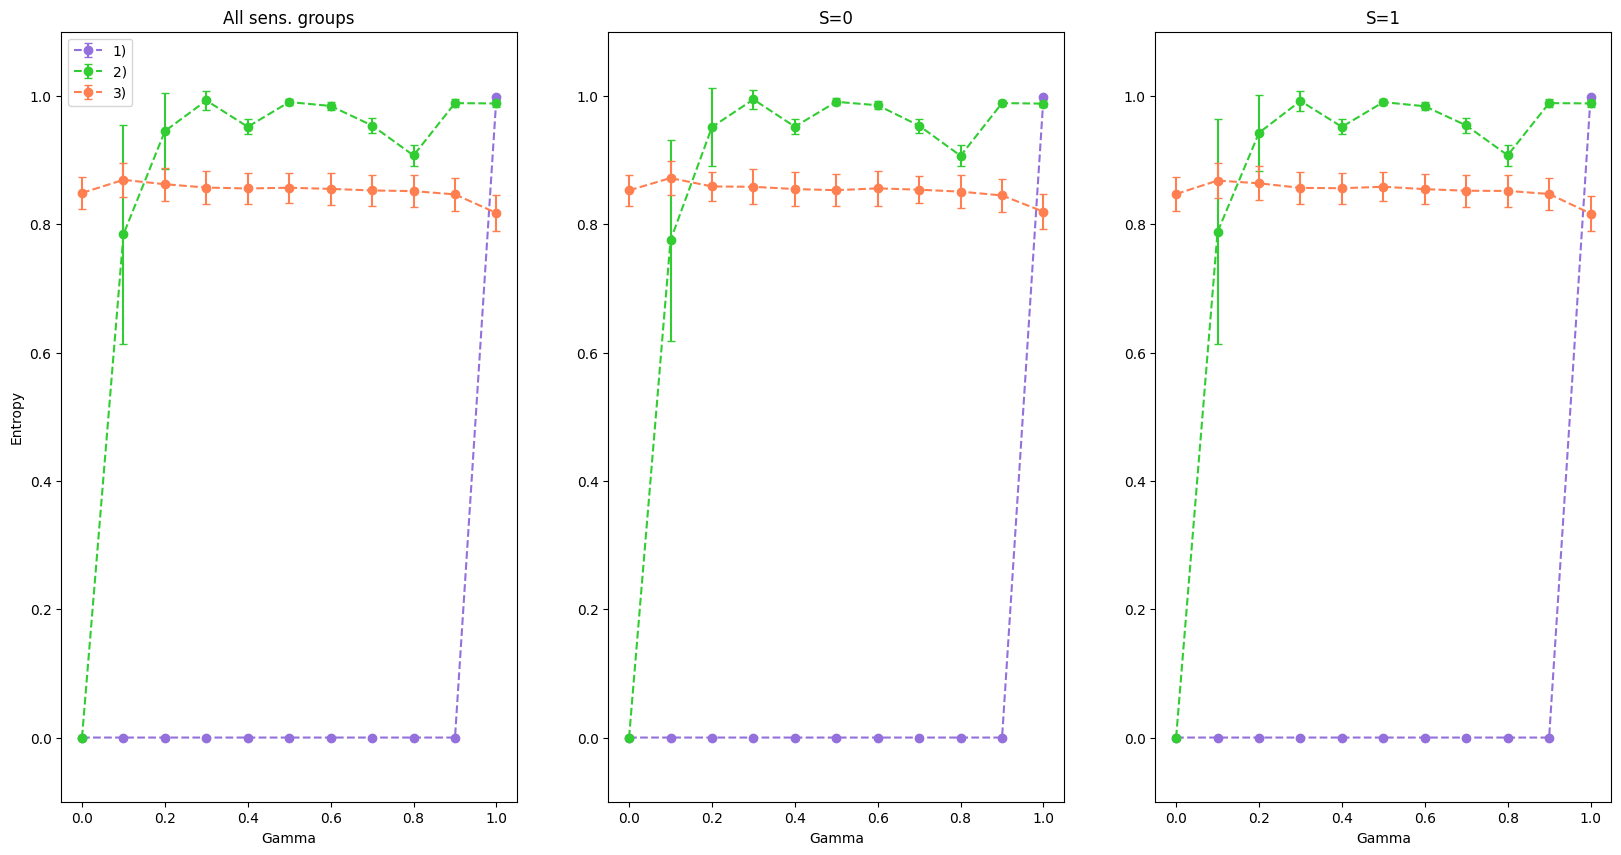

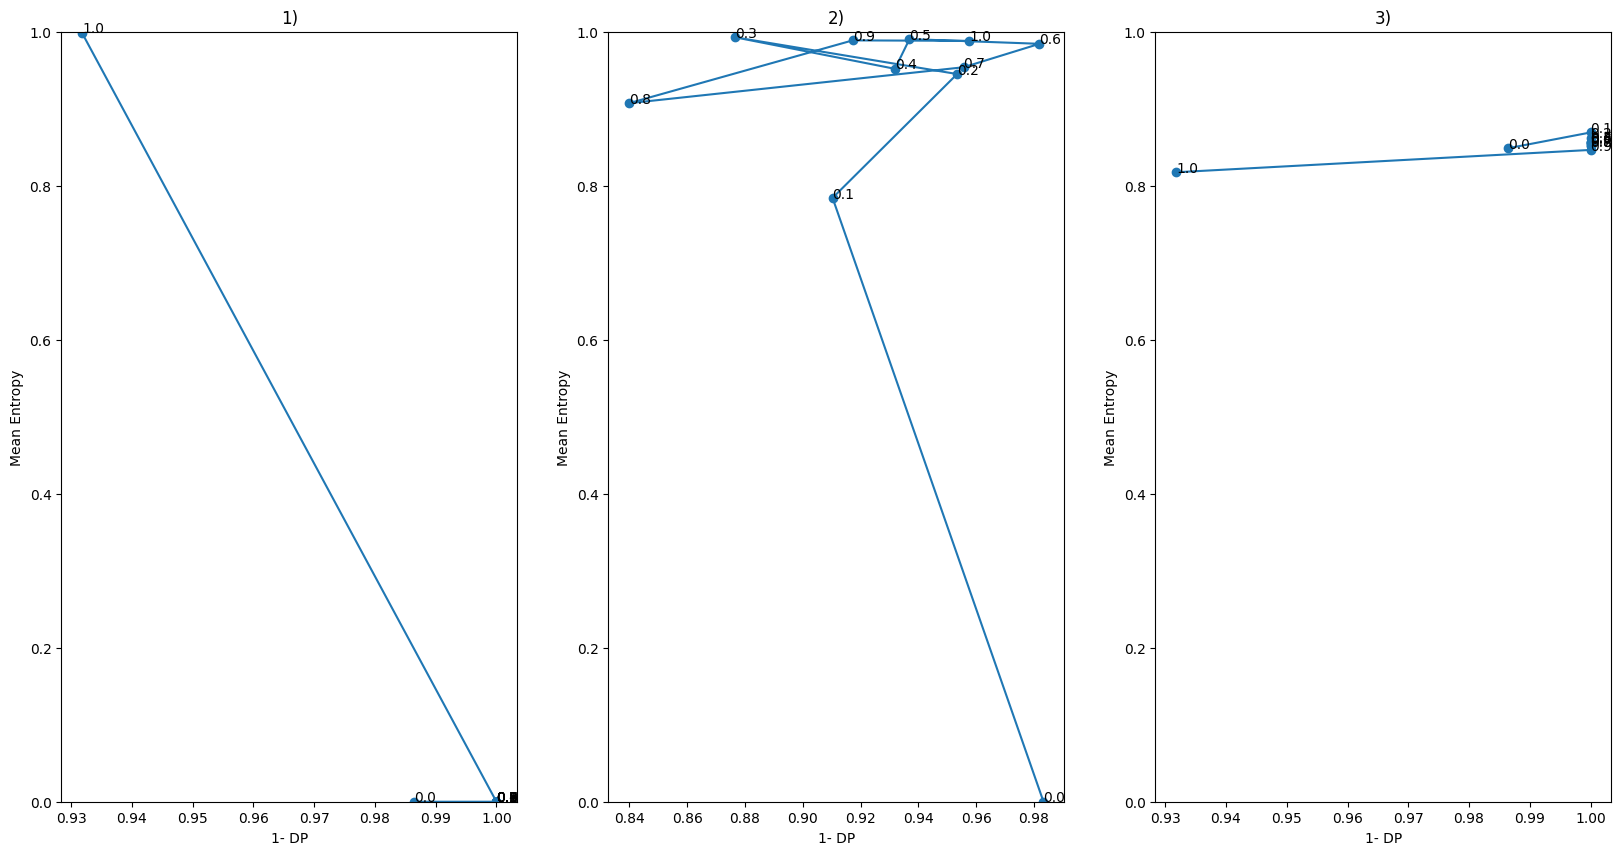

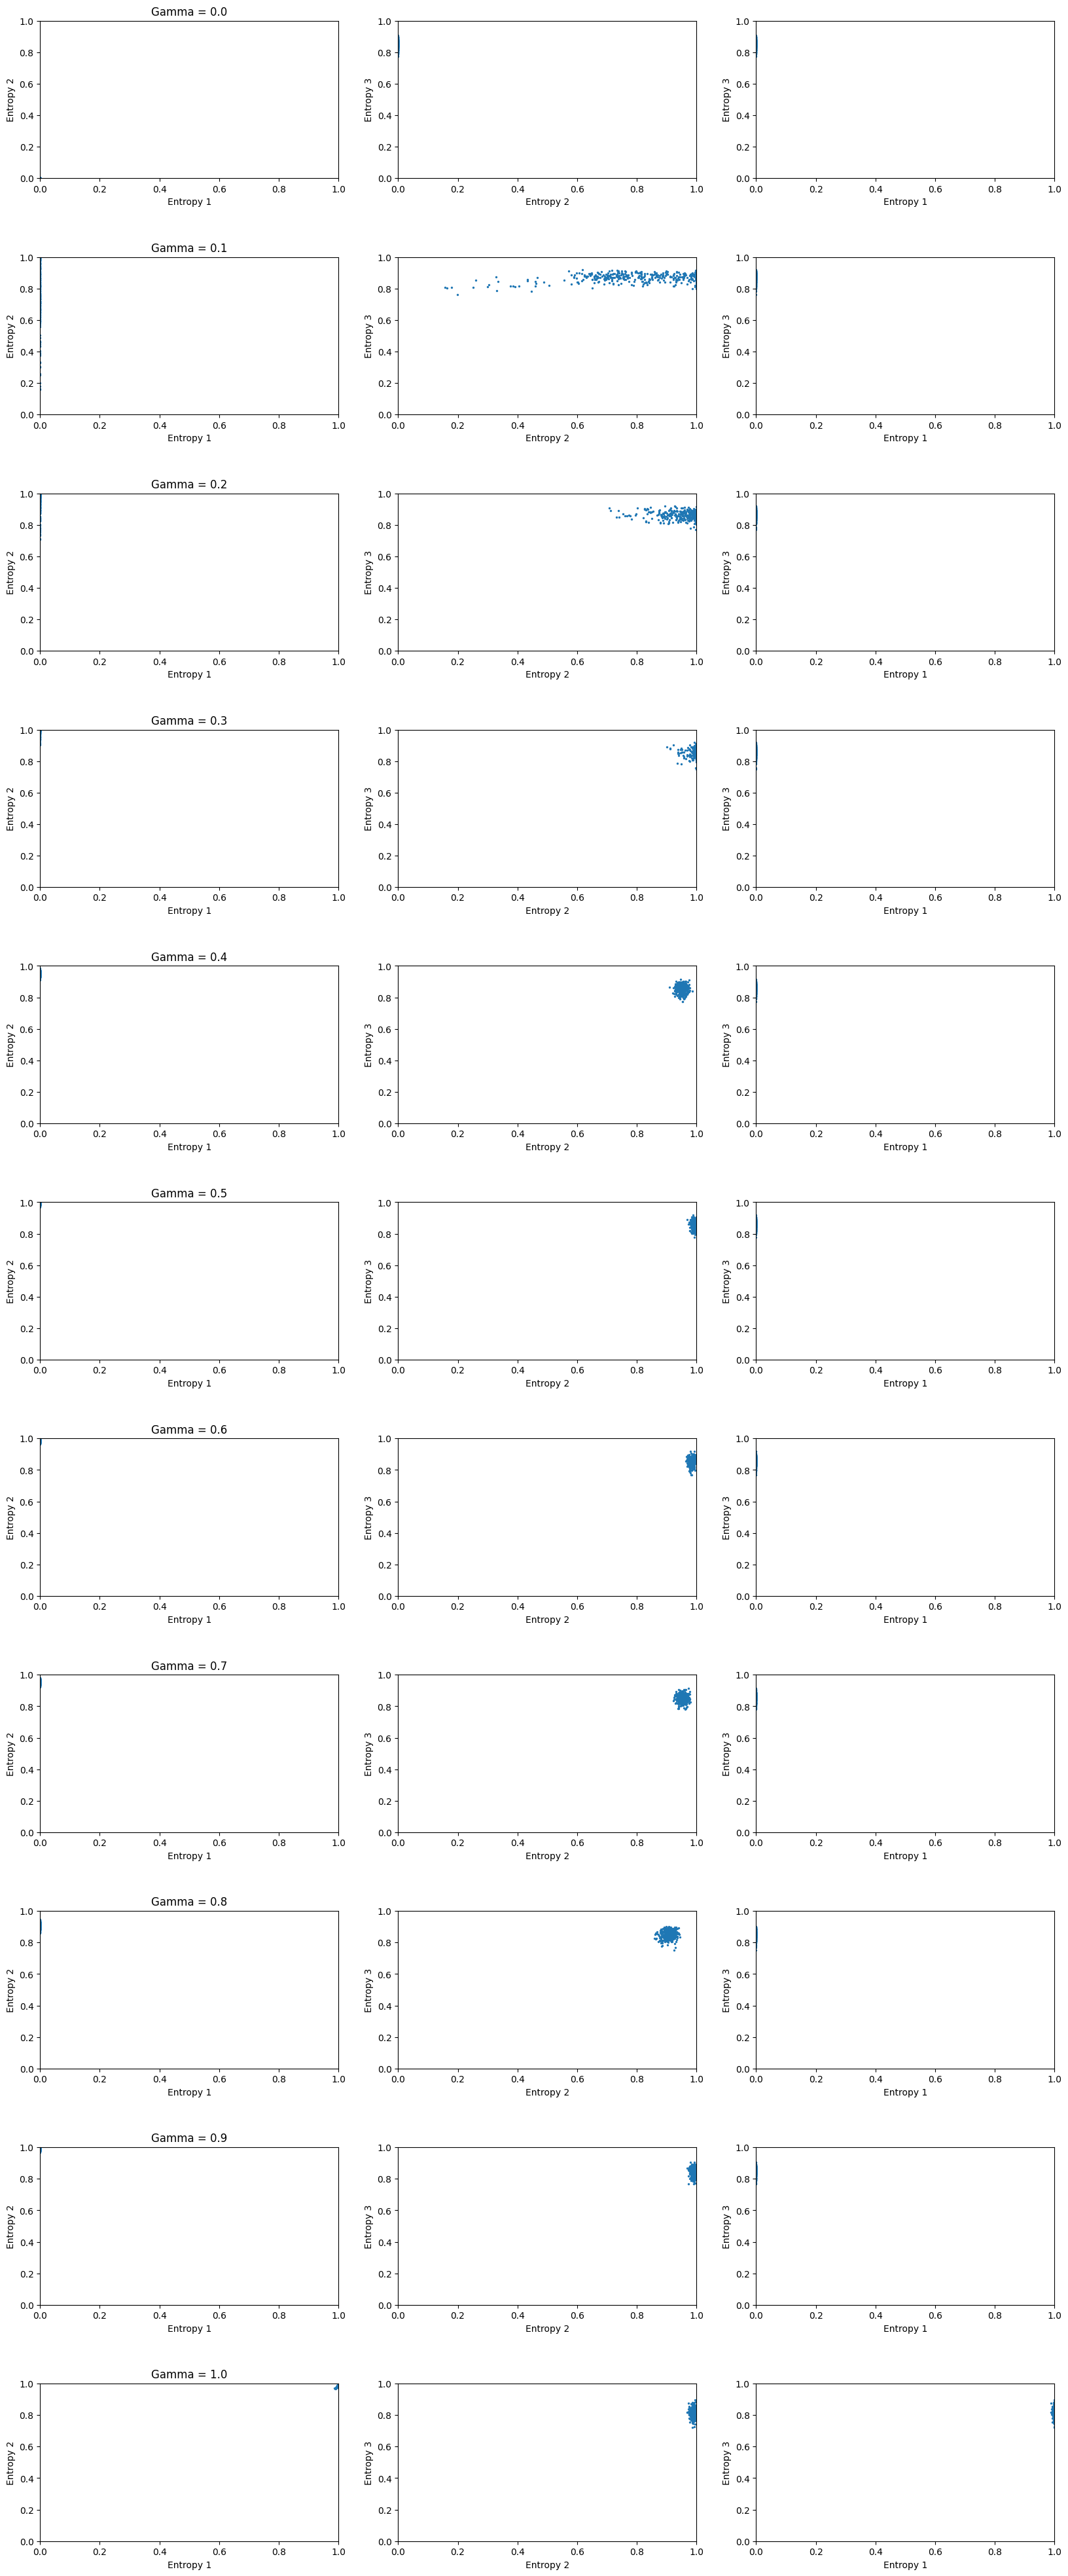

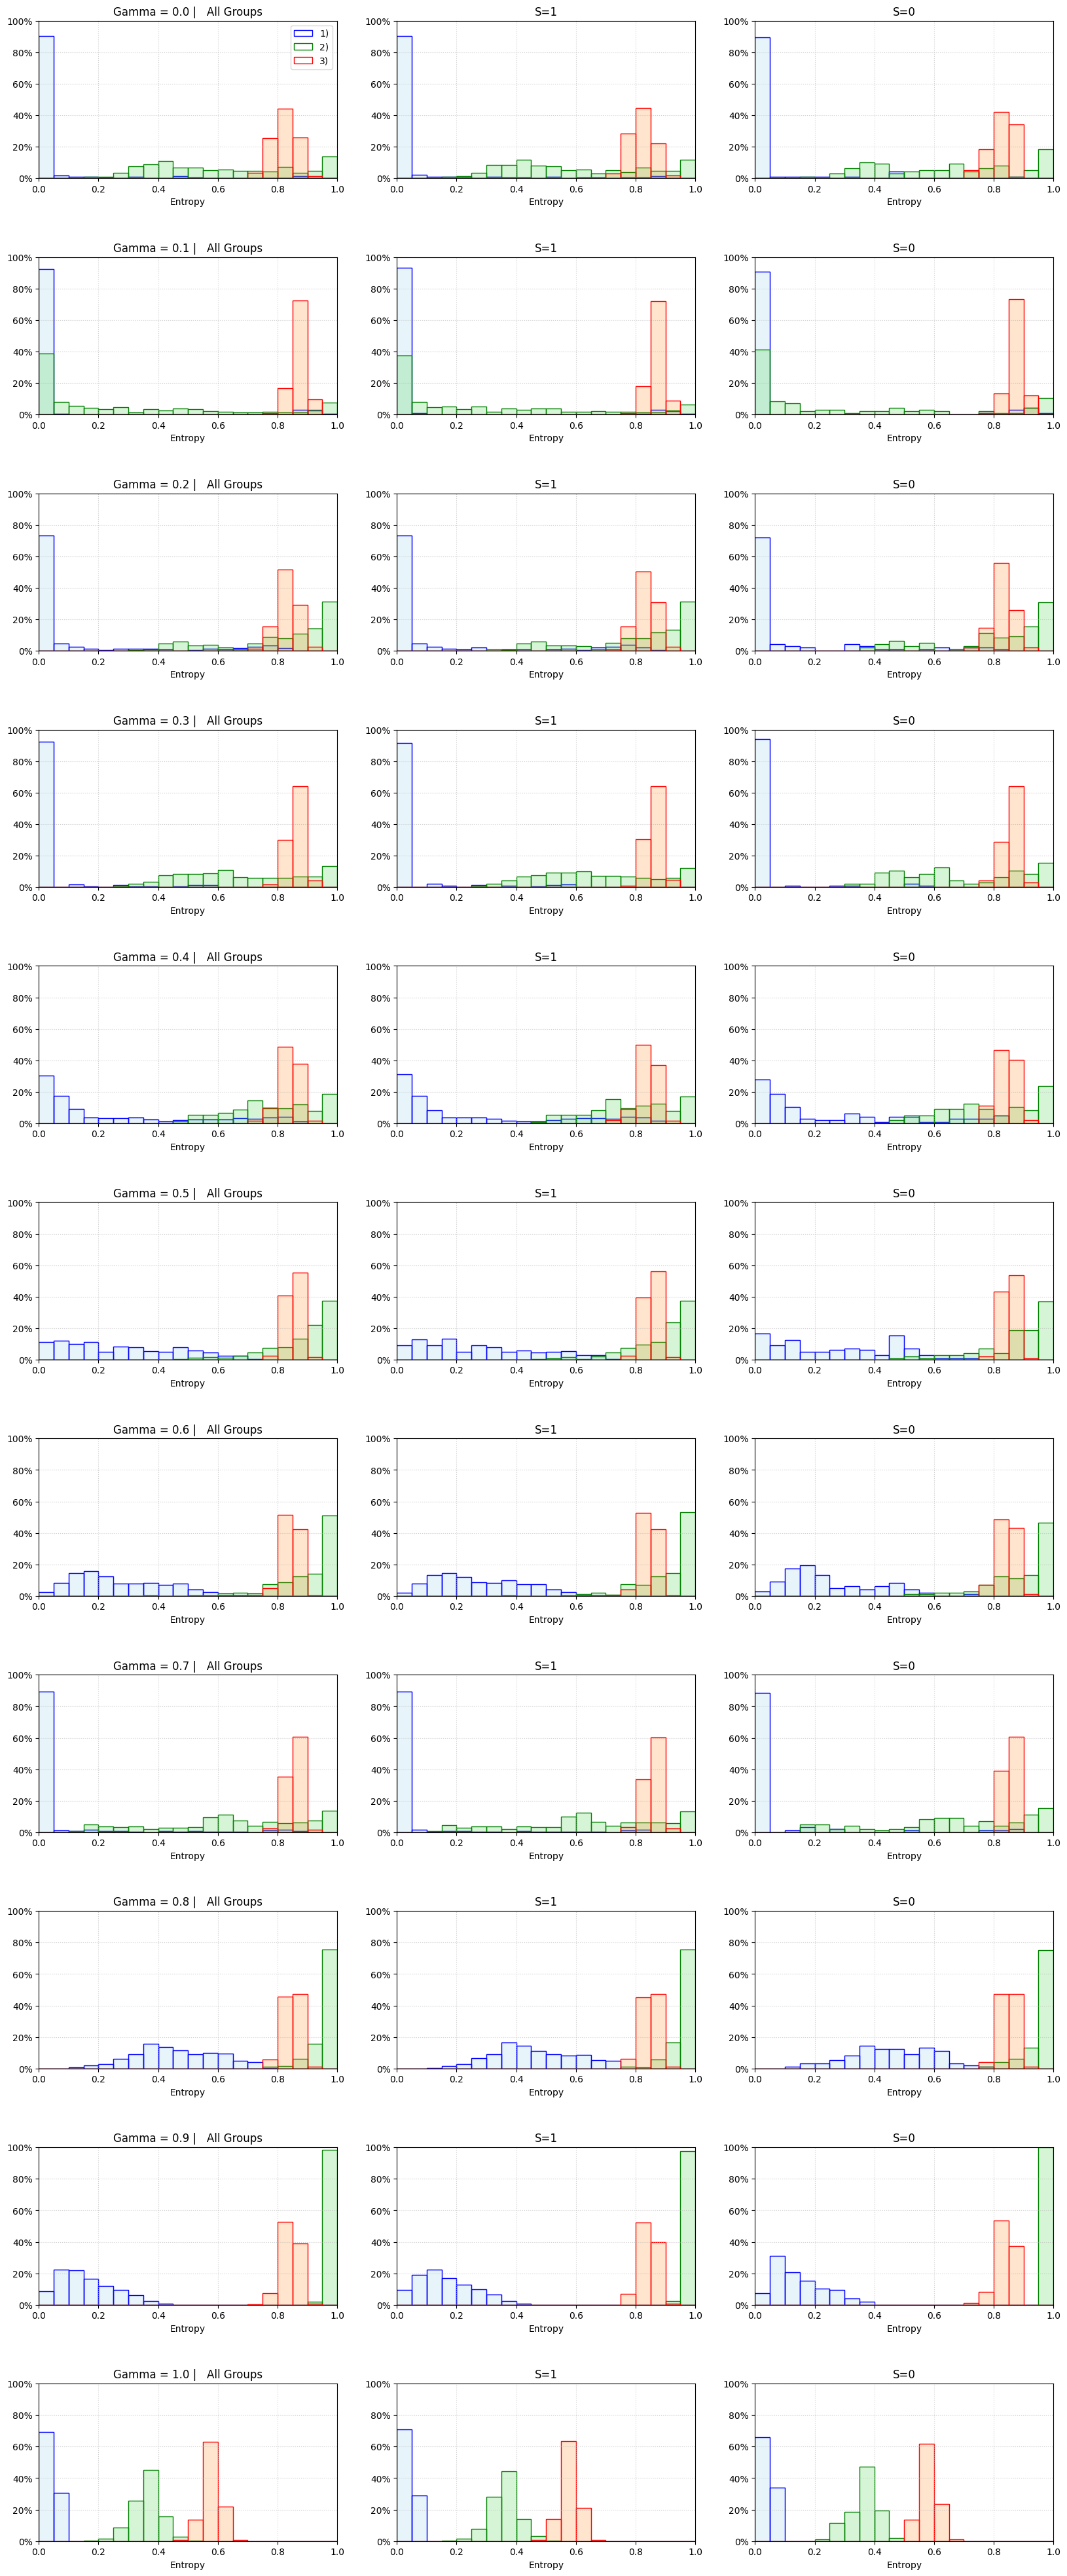

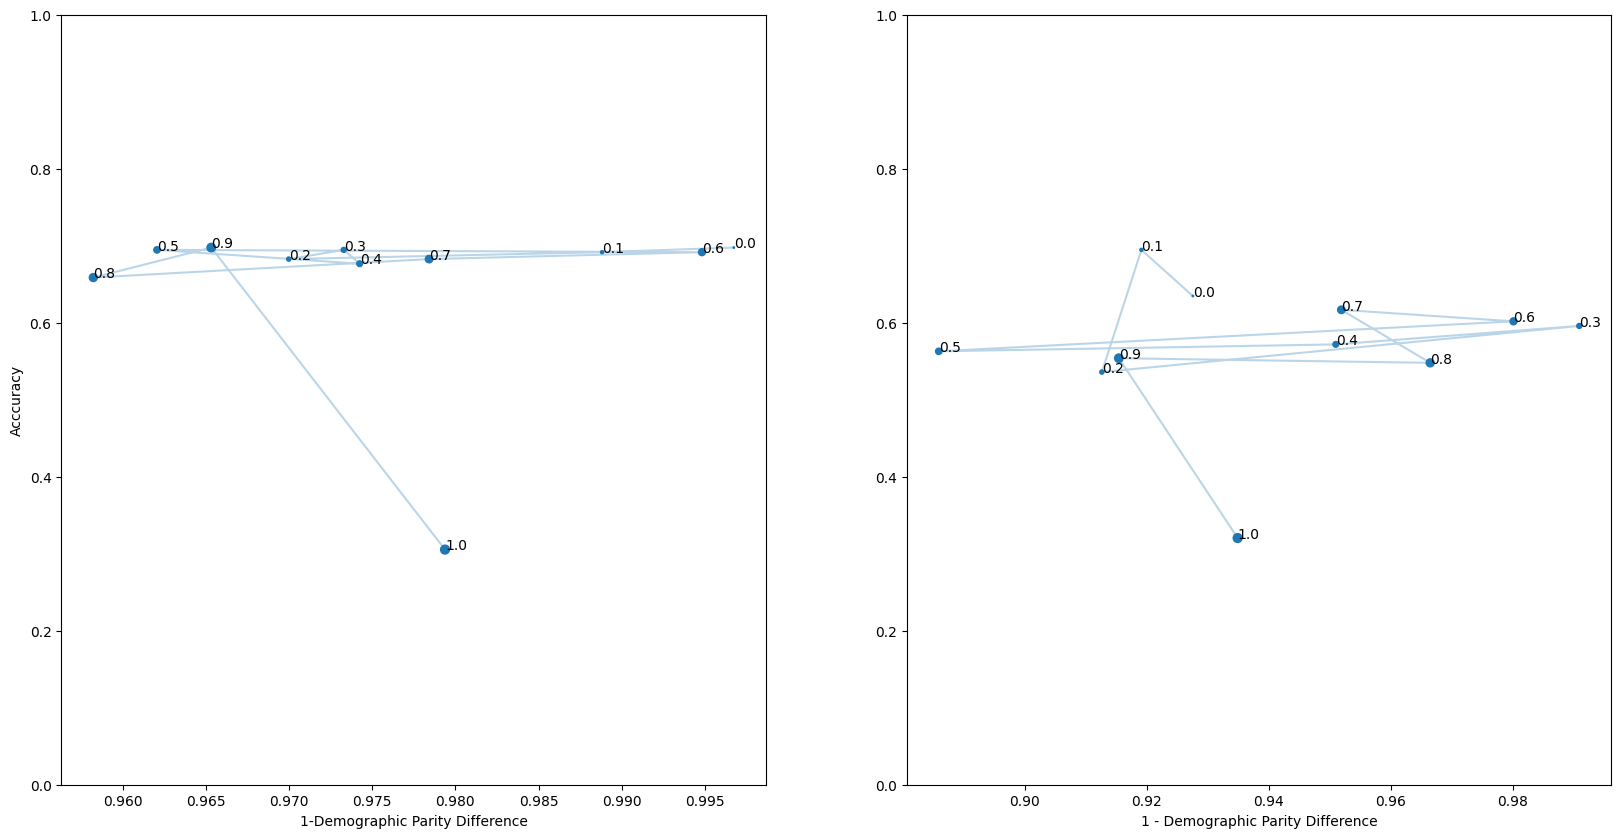

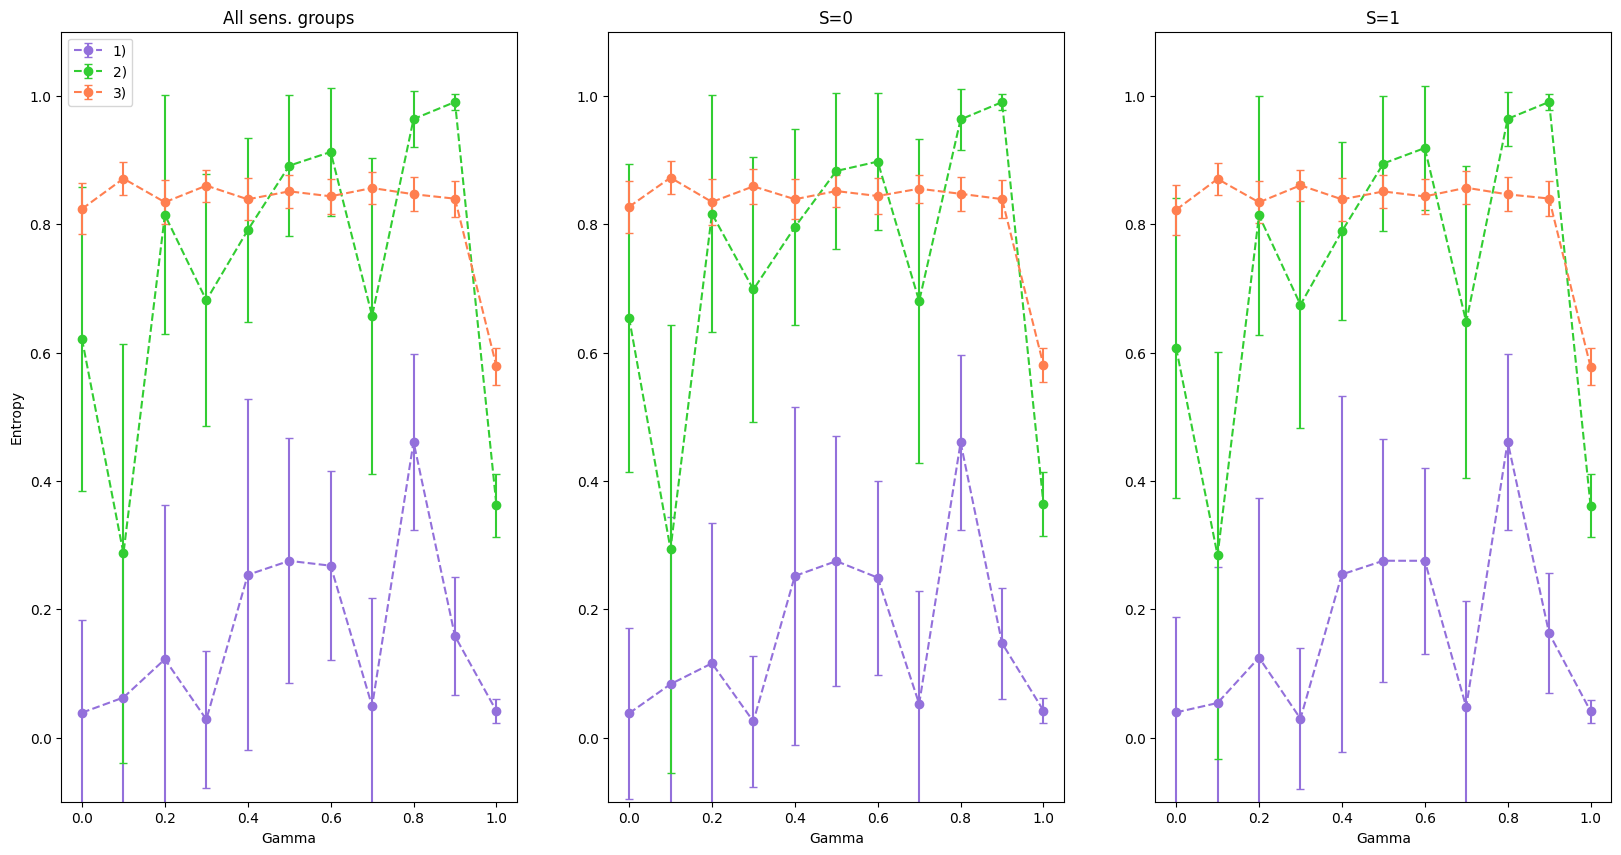

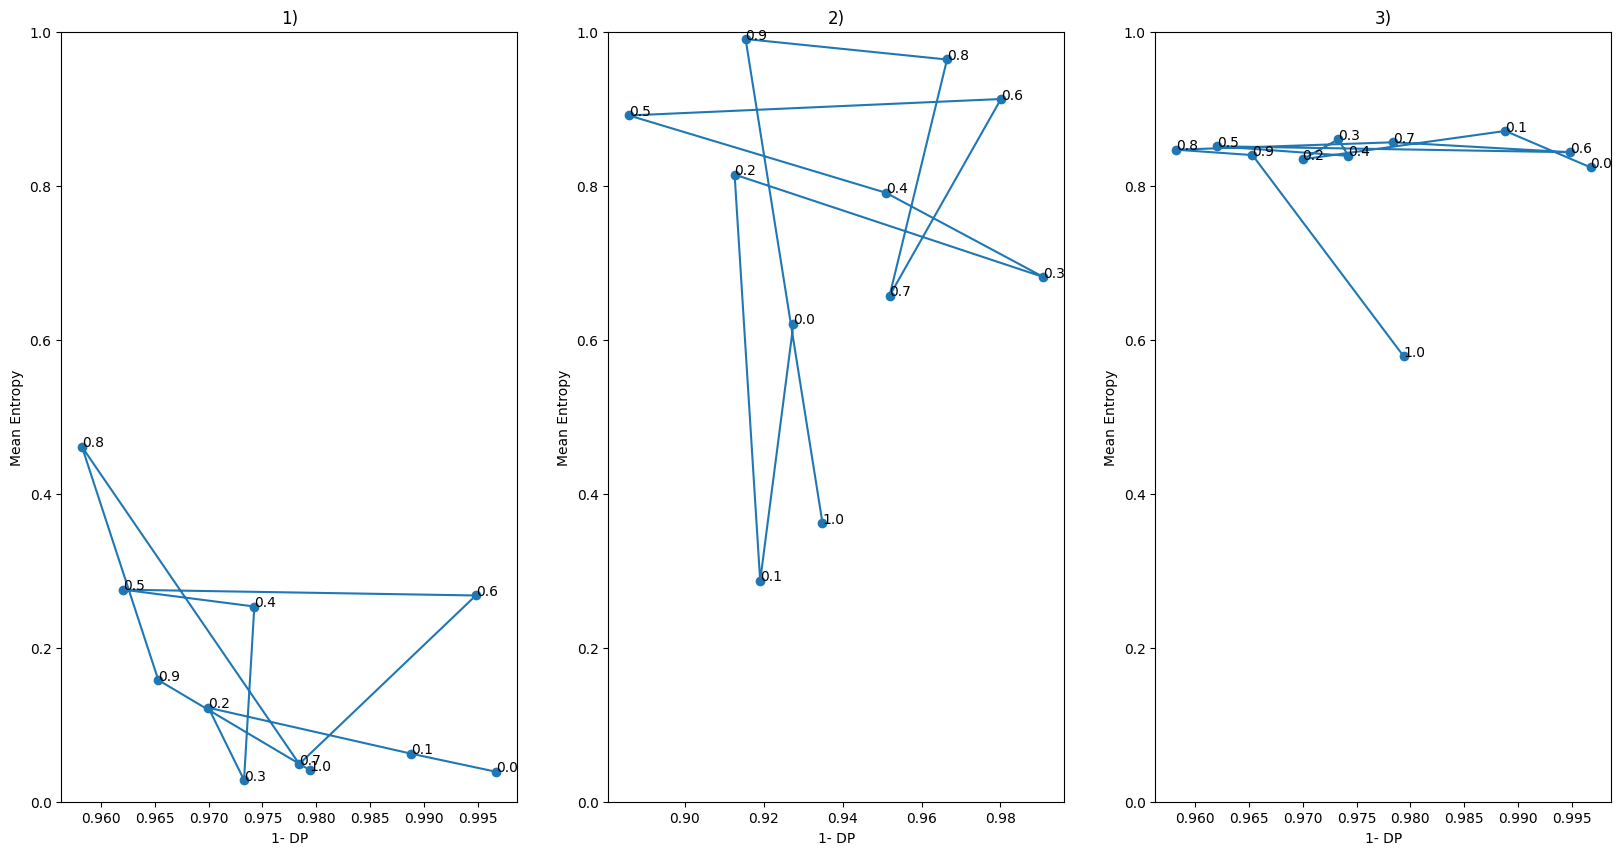

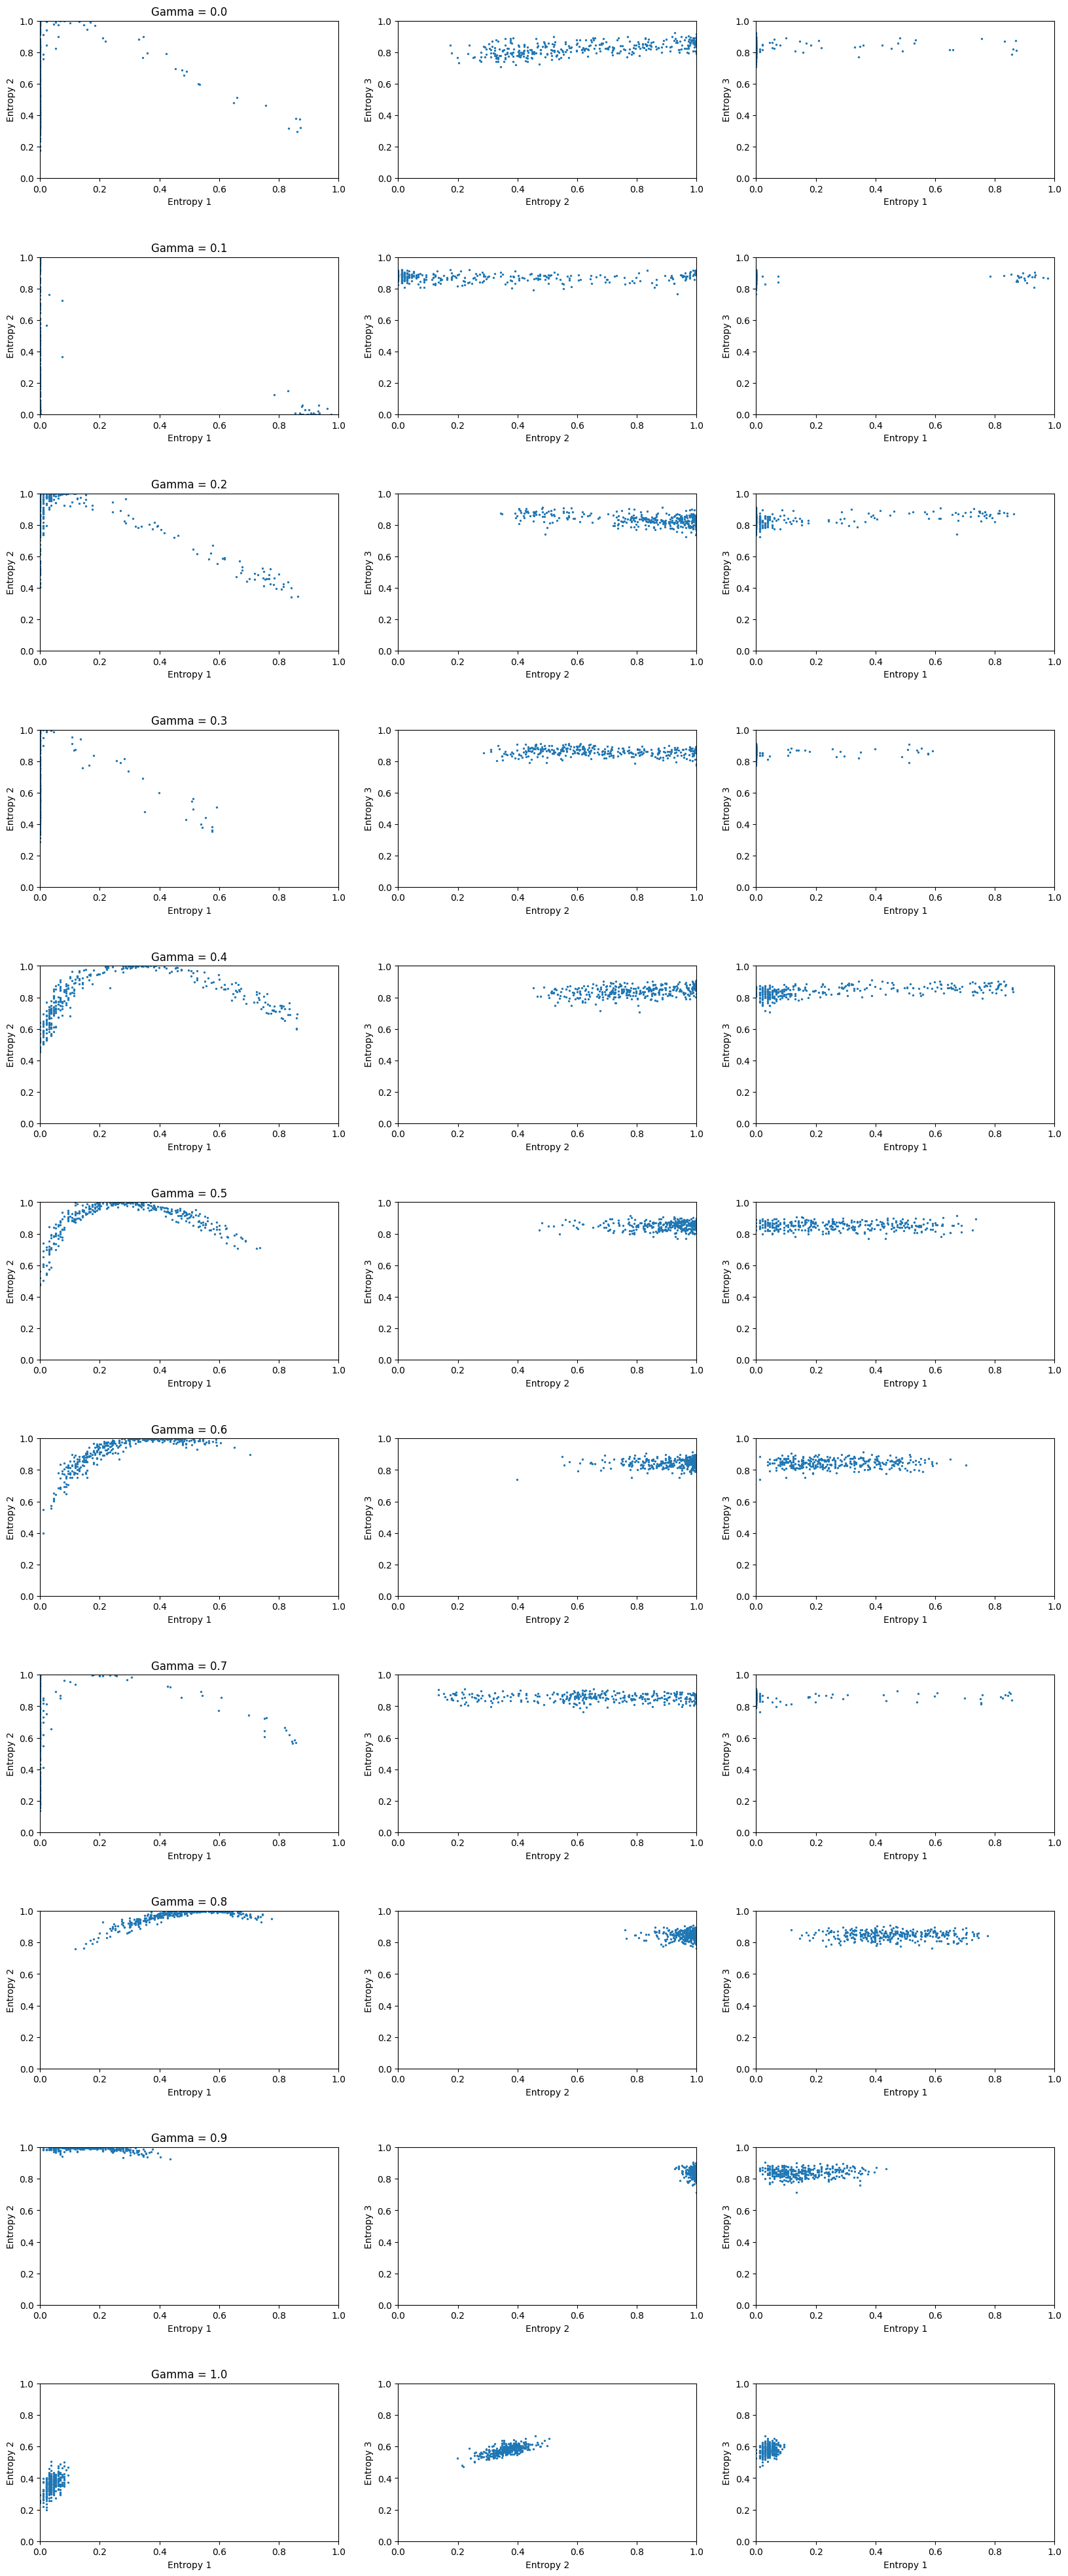

In [26]:
main("../results/results_04-12-2025","../results/results_04-12-2025/plots")